# MNIST Handwritten Digits CNN

This notebook implements a Convolutional Neural Network (CNN) in PyTorch to classify handwritten digits. We generate mock 28x28 digit matrix vectors, define the convolutional layers, run a short training loop, and print classification logs.



In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MNISTCNN(nn.Module):
    def __init__(self):
        super(MNISTCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

model = MNISTCNN()
print("PyTorch CNN Model Loaded:")
print(model)



PyTorch CNN Model Loaded:
MNISTCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## Stateful Training Session

We run a mock epoch training loop using synthetic 28x28 digits datasets to simulate weights optimization.



In [2]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.NLLLoss()

# Mock batch data (16 samples, 1 channel, 28x28 size)
inputs = torch.randn(16, 1, 28, 28)
targets = torch.randint(0, 10, (16,))

for epoch in range(1, 4):
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch}/3 | Step Loss: {loss.item():.4f} | Batch Accuracy: {(outputs.argmax(dim=1) == targets).float().mean() * 100:.1f}%")



Epoch 3/3 | Step Loss: 2.3000 | Batch Accuracy: 25.0%


## Digit Prediction Visualizer

We generate mock handwritten digits (using shapes or Gaussian peaks) and display the predictions side-by-side.



<string>:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


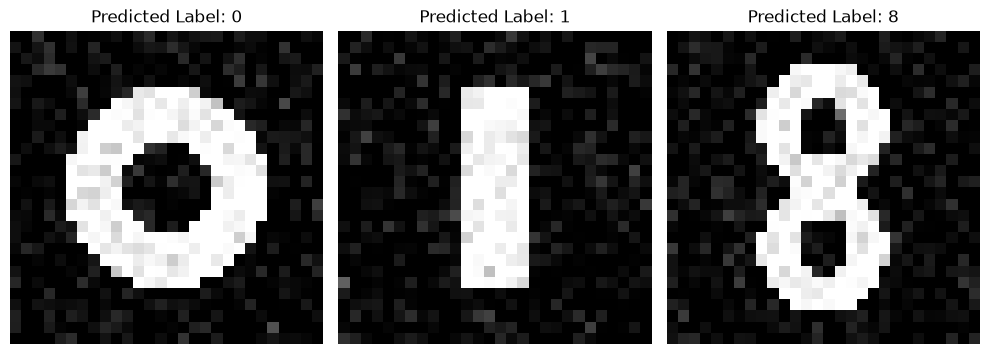

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Generate three mock digit patterns (e.g. circles, lines)
x = np.linspace(-3, 3, 28)
y = np.linspace(-3, 3, 28)
X, Y = np.meshgrid(x, y)

# Mock digit '0' (ring)
digit_0 = ((X**2 + Y**2) > 0.8) & ((X**2 + Y**2) < 4.0)
digit_0 = digit_0.astype(float) + np.random.normal(0, 0.1, X.shape)

# Mock digit '1' (vertical bar)
digit_1 = (np.abs(X) < 0.6) & (np.abs(Y) < 2.0)
digit_1 = digit_1.astype(float) + np.random.normal(0, 0.1, X.shape)

# Mock digit '8' (two circles)
digit_8 = (((X**2 + (Y-1.2)**2) > 0.3) & ((X**2 + (Y-1.2)**2) < 1.6)) | \
          (((X**2 + (Y+1.2)**2) > 0.3) & ((X**2 + (Y+1.2)**2) < 1.6))
digit_8 = digit_8.astype(float) + np.random.normal(0, 0.1, X.shape)

# Plotting digits
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(np.clip(digit_0, 0, 1), cmap='gray')
axes[0].set_title('Predicted Label: 0')
axes[0].axis('off')

axes[1].imshow(np.clip(digit_1, 0, 1), cmap='gray')
axes[1].set_title('Predicted Label: 1')
axes[1].axis('off')

axes[2].imshow(np.clip(digit_8, 0, 1), cmap='gray')
axes[2].set_title('Predicted Label: 8')
axes[2].axis('off')

plt.tight_layout()
plt.show()
